# Demo 06 - Surface diagnostics, SVI calibration/repair, and interpolation choices

This notebook builds an implied surface from a shared synthetic quote set, compares raw-grid and fitted representations, makes no-arbitrage diagnostics explicit, and inspects repair and interpolation choices that matter before any Dupire-style handoff.

- compare raw quotes, the raw grid, and the repaired SVI surface
- inspect no-arbitrage diagnostics, fit quality, and repair outcomes
- benchmark the repair path on the Gatheral-Jacquier reference case
- compare interpolation choices on a common probe maturity

`PROFILE = "quick"` keeps the run short; switch to `PROFILE = "full"` for denser diagnostics.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'src' / 'option_pricing').exists():
            return candidate
    return start

ROOT = _find_repo_root(Path.cwd())
SRC = ROOT / 'src'
if SRC.exists() and str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import matplotlib.pyplot as plt  # noqa: E402
import pandas as pd  # noqa: E402
from IPython.display import display  # noqa: E402

pd.set_option('display.max_columns', None)
PROFILE = 'quick'
SEED = 7

from option_pricing.demos import (  # noqa: E402
    build_shared_demo_scenario,
    build_surface_demo_artifacts,
)
from option_pricing.diagnostics.vol_surface import plot as vs_plot  # noqa: E402

scenario = build_shared_demo_scenario(profile=PROFILE, seed=SEED)
art = build_surface_demo_artifacts(
    profile=PROFILE,
    seed=SEED,
    scenario=scenario,
)

headline = pd.DataFrame(
    [
        {
            'profile': art.profile,
            'repair_mode_used': art.meta['svi_repair_mode_used'],
            'repair_fallback_used': art.meta['svi_repair_fallback_used'],
            'focus_expiry_T': art.meta['focus_T'],
            'interpolation_probe_T': art.meta['interpolation_probe_T'],
            'gj_benchmark_loaded': art.reports.get('gj51') is not None,
            'next_demo': '07_essvi_smooth_surface_for_dupire',
        }
    ]
)
display(headline)

,profile,repair_mode_used,repair_fallback_used,focus_expiry_T,interpolation_probe_T,gj_benchmark_loaded,next_demo
0,quick,robust_all_line_search,False,2.0,0.415,True,07_essvi_smooth_surface_for_dupire


## 1) Build the quote set and compare surface candidates

The shared scenario keeps the raw grid, repaired SVI surface, and no-arbitrage checks on the same market inputs.

,T,n_quotes,iv_obs_min,iv_obs_max,mean_abs_noise_bp
0,0.10,31,0.198002,0.344461,7.009819
1,0.15,31,0.205030,0.308949,6.692462
2,0.20,31,0.210328,0.291483,6.351922
3,0.25,31,0.213555,0.281815,6.985789
4,0.33,31,0.219184,0.270194,7.475755
5,0.50,31,0.228081,0.263668,6.752014
6,0.75,31,0.238333,0.264497,9.015742
7,1.00,31,0.247110,0.266082,7.183411
8,1.25,31,0.254239,0.268964,8.603609
9,1.50,31,0.261457,0.273378,6.262839


,surface,ok,calendar_ok,calendar_max_violation,message
0,truth_grid (latent benchmark),True,True,0.000000,"OK, mono_bad=0/11, butterfly_bad=0/11, calenda..."
1,grid (observed quotes),False,True,0.000000,"Violations found, mono_bad=0/11, butterfly_bad..."
2,svi_no_repair,False,False,0.032524,"Violations found, mono_bad=0/11, butterfly_bad..."
3,svi_repaired,False,False,0.032524,"Violations found, mono_bad=0/11, butterfly_bad..."


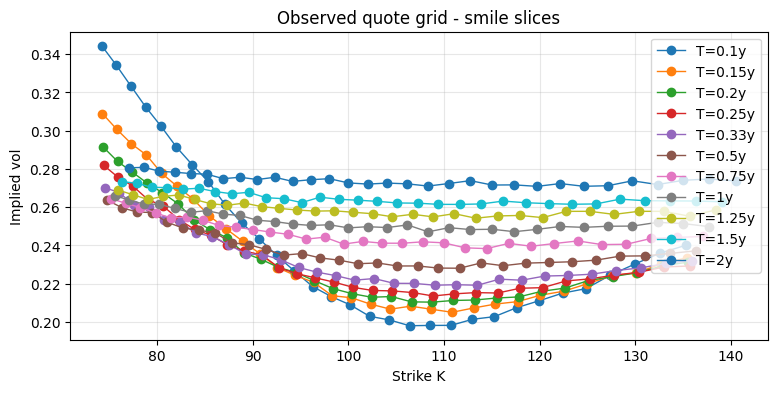

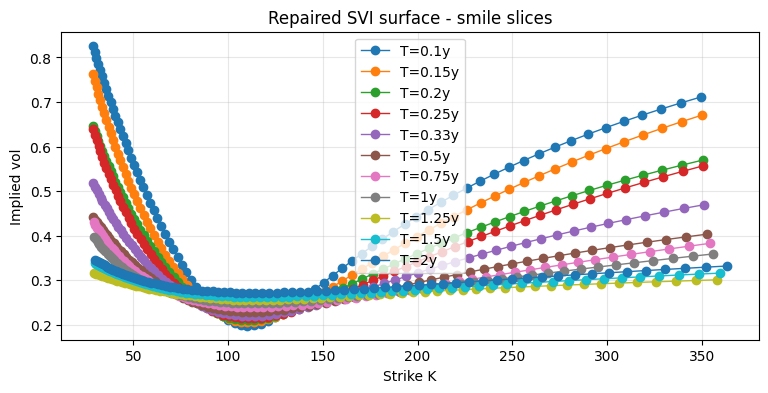

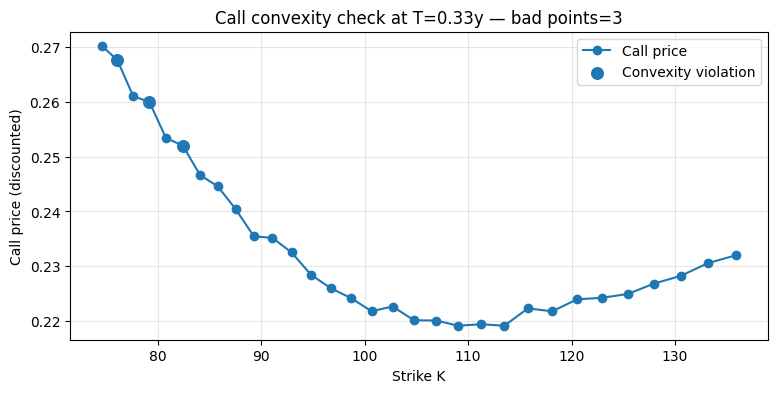

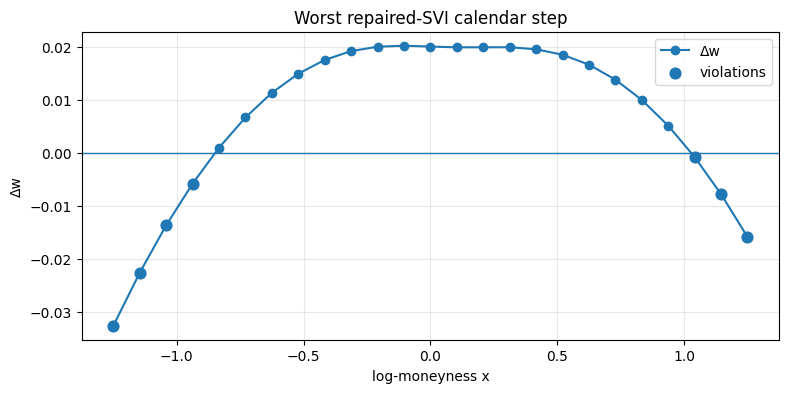

In [2]:
display(art.tables['quote_summary'])
display(
    art.tables['surface_noarb_summary'][
        ['surface', 'ok', 'calendar_ok', 'calendar_max_violation', 'message']
    ]
)

vs_plot.plot_smile_slices(
    art.surfaces['grid'],
    forward=art.scenario.forward,
    title='Observed quote grid - smile slices',
)
vs_plot.plot_smile_slices(
    art.surfaces['svi_repaired'],
    forward=art.scenario.forward,
    title='Repaired SVI surface - smile slices',
)
vs_plot.plot_first_convexity_violation(
    art.surfaces['grid'],
    art.reports['noarb_grid'],
    forward=art.scenario.forward,
    df=art.scenario.discount,
)
vs_plot.plot_worst_calendar_slice(
    art.surfaces['svi_repaired'],
    art.reports['noarb_svi_repaired'],
    title='Worst repaired-SVI calendar step',
)


## 2) Inspect SVI fit quality, flagged slices, and repair outcomes

This section keeps the slice diagnostics, repair attempts, and before/after evidence visible so the fitted surface can be audited rather than taken on faith.

,T,diag_ok_nr,rmse_w_nr,mae_w_nr,min_g_nr,butterfly_ok_nr,failure_reason_nr,diag_ok_fx,rmse_w_fx,mae_w_fx,min_g_fx,butterfly_ok_fx,failure_reason_fx
0,0.10,True,0.000093,0.000070,0.026640,True,,True,0.000093,0.000070,0.026640,True,
1,0.15,True,0.000115,0.000096,0.005219,True,,True,0.000115,0.000096,0.005226,True,
2,0.20,True,0.000114,0.000093,0.036877,True,,True,0.000114,0.000093,0.036883,True,
3,0.25,False,0.000134,0.000105,-0.000634,False,g_below_floor,False,0.000134,0.000105,-0.000635,False,g_below_floor
4,0.33,True,0.000169,0.000147,0.073815,True,,True,0.000169,0.000147,0.073822,True,
5,0.50,True,0.000222,0.000170,0.143934,True,,True,0.000222,0.000170,0.143941,True,
6,0.75,False,0.000340,0.000282,-0.000886,False,g_below_floor,False,0.000340,0.000282,-0.000888,False,g_below_floor
7,1.00,False,0.000446,0.000353,-0.015580,False,g_below_floor,False,0.000446,0.000353,-0.015581,False,g_below_floor
8,1.25,True,0.000684,0.000526,0.332356,True,,True,0.000684,0.000526,0.332356,True,
9,1.50,True,0.000642,0.000495,0.267266,True,,True,0.000642,0.000495,0.267264,True,


,T,diag_ok_nr,rmse_w_nr,mae_w_nr,min_g_nr,butterfly_ok_nr,failure_reason_nr,diag_ok_fx,rmse_w_fx,mae_w_fx,min_g_fx,butterfly_ok_fx,failure_reason_fx
3,0.25,False,0.000134,0.000105,-0.000634,False,g_below_floor,False,0.000134,0.000105,-0.000635,False,g_below_floor
6,0.75,False,0.000340,0.000282,-0.000886,False,g_below_floor,False,0.000340,0.000282,-0.000888,False,g_below_floor
7,1.00,False,0.000446,0.000353,-0.015580,False,g_below_floor,False,0.000446,0.000353,-0.015581,False,g_below_floor


,label,ok,error
0,robust_all_line_search,True,


,base_source,generator_source,good_ok,bad_ok,rho_abs,mode,b_base,b_bad,b_mult_eff,sigma_base,sigma_bad,sigma_mult_eff,b_wing_threshold,good_min_g,bad_min_g,bad_failure_reason,y_min,y_max,T
0,focus_slice_params,from_base_params,True,False,0.95,forced_wing,0.154309,1.046677,6.782982,1.204221,1.083799,0.9,1.026154,0.230113,-0.01036,"wing_limit_violation (gL_inf=0.25, gR_inf=-0.0...",-1.25,1.25,2.0


,stage,ok,min_g,min_g_plot,argmin_plot,lee_ok,params,failure_reason
0,before_repair,False,-1.036017e-02,0.046145,1.25,False,"SVIParams(a=-0.03796155644103699, b=1.04667692...","wing_limit_violation (gL_inf=0.25, gR_inf=-0.0..."
1,after_repair,True,-9.999968e-11,0.146496,1.25,True,"SVIParams(a=-0.05311322764695281, b=0.88018504...",None


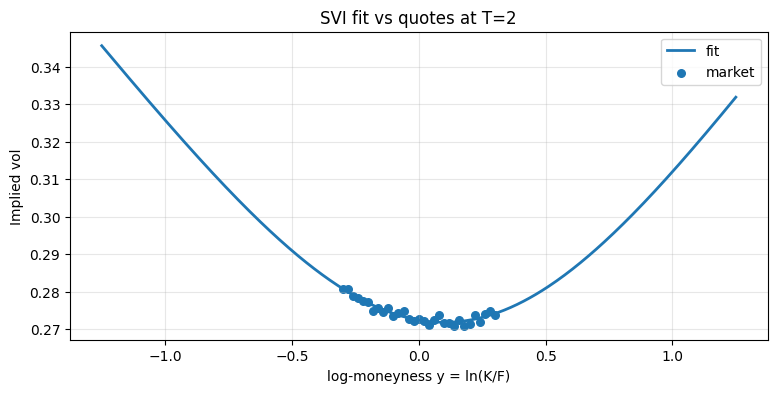

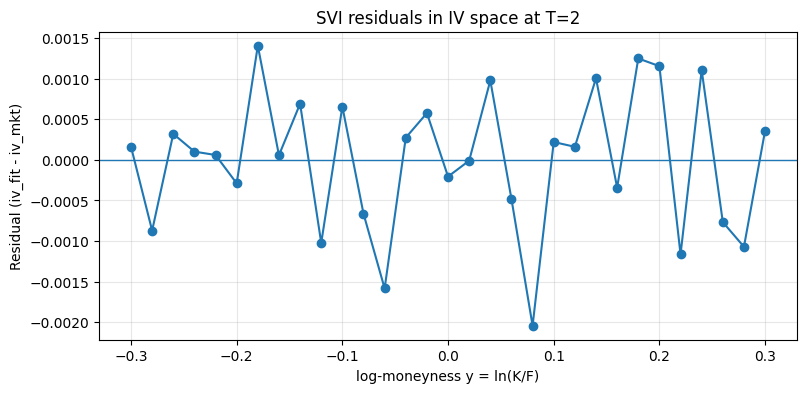

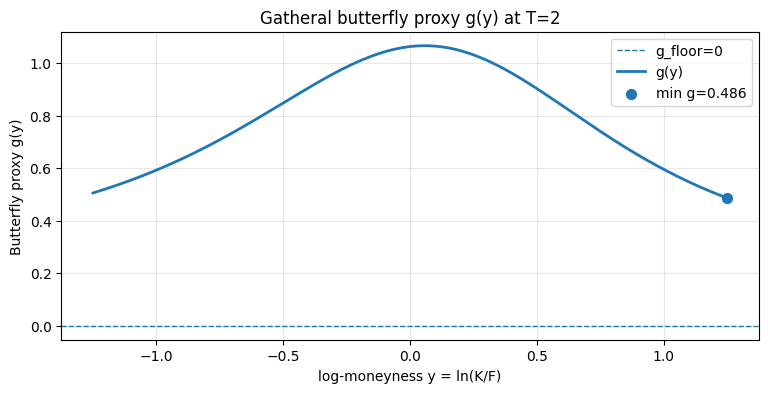

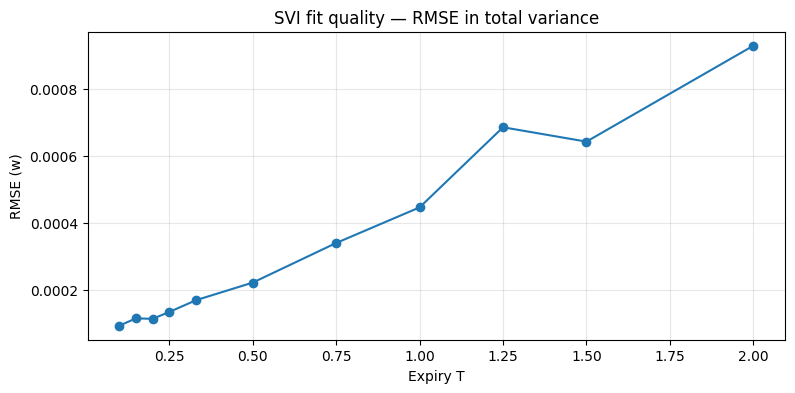

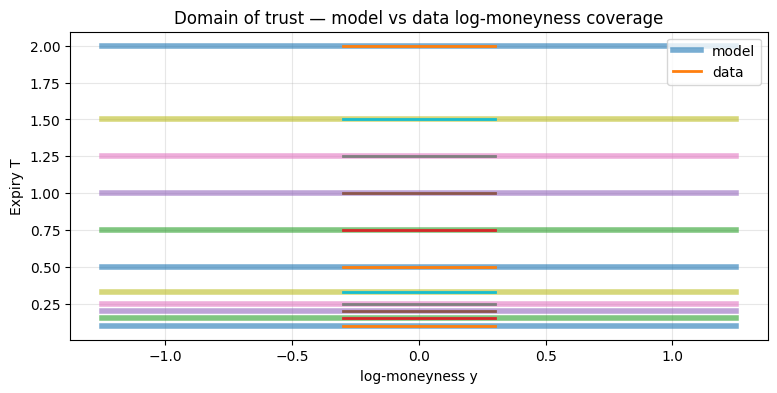

In [3]:
svi_compare = art.tables['svi_fit_compare'].copy()
flagged = svi_compare.loc[
    (~svi_compare['diag_ok_nr'].fillna(True))
    | (~svi_compare['diag_ok_fx'].fillna(True))
    | (~svi_compare['butterfly_ok_nr'].fillna(True))
    | (~svi_compare['butterfly_ok_fx'].fillna(True))
].copy()

display(svi_compare)
if not flagged.empty:
    display(flagged)

display(art.tables['svi_repair_attempts'])
failure_summary = art.tables['svi_repair_failure_summary']
if not failure_summary.empty:
    display(failure_summary)

display(art.tables['explicit_repair_metadata'])
display(art.tables['explicit_repair_summary'])

quotes_for_plots = art.tables['quotes_df'].rename(columns={'iv_obs': 'iv'})[['T', 'K', 'iv']]
focus_T = float(art.meta['focus_T'])

vs_plot.plot_svi_fit_slice(
    art.surfaces['svi_repaired'],
    T=focus_T,
    forward=art.scenario.forward,
    quotes_df=quotes_for_plots,
    kind='iv',
    title=f'SVI fit vs quotes at T={focus_T:g}',
)
vs_plot.plot_svi_residuals(
    art.surfaces['svi_repaired'],
    T=focus_T,
    forward=art.scenario.forward,
    quotes_df=quotes_for_plots,
    kind='iv',
    title=f'SVI residuals in IV space at T={focus_T:g}',
)
vs_plot.plot_butterfly_proxy(
    art.surfaces['svi_repaired'],
    T=focus_T,
    title=f'Gatheral butterfly proxy g(y) at T={focus_T:g}',
)
vs_plot.plot_svi_rmse_by_expiry(art.surfaces['svi_repaired'])
vs_plot.plot_surface_domain_report(
    art.surfaces['svi_repaired'],
    quotes_df=quotes_for_plots,
    forward=art.scenario.forward,
)


## 3) Benchmark the repair path on the GJ reference case

The published Gatheral-Jacquier Example 5.1 benchmark gives a second check on the repair path outside the shared synthetic scenario.

<>:9: SyntaxWarning: invalid escape sequence '\.'
<>:9: SyntaxWarning: invalid escape sequence '\.'
C:\Users\ouwez\AppData\Local\Temp\ipykernel_1996\661056821.py:9: SyntaxWarning: invalid escape sequence '\.'
  gj_cmp['quantity'].str.contains('JW\.|Section 5.1 target|Projected', regex=True)


,max_abs_error_vs_paper_targets,mean_abs_error_vs_paper_targets,projected_min_g,optimal_min_g
0,2.189864e-07,3.604239e-08,0.253491,-9.434344e-11


,quantity,computed,paper,abs_error_vs_paper
0,JW.v,0.017426,0.017426,2.555159e-09
1,JW.psi,-0.175211,-0.175211,4.080913e-08
2,JW.p,0.699738,0.699738,4.116809e-09
3,JW.c,1.316798,1.316798,2.189864e-07
4,JW.v_tilde,0.011625,0.011625,3.235478e-09
5,Section 5.1 target c0,0.349316,0.349316,2.249856e-08
6,Section 5.1 target vtilde0,0.015482,0.015482,4.840731e-09
7,Projected c0 (actual),0.349316,0.349316,2.249856e-08
8,Projected vtilde0 (actual),0.015482,0.015482,4.840731e-09
9,Optimal c*,1.064430,0.856476,2.079541e-01


,stage,ok,min_g,failure_reason
0,orig,False,-3.286357e-02,g_below_floor
1,projected,True,2.534913e-01,None
2,optimal,True,-9.434344e-11,None


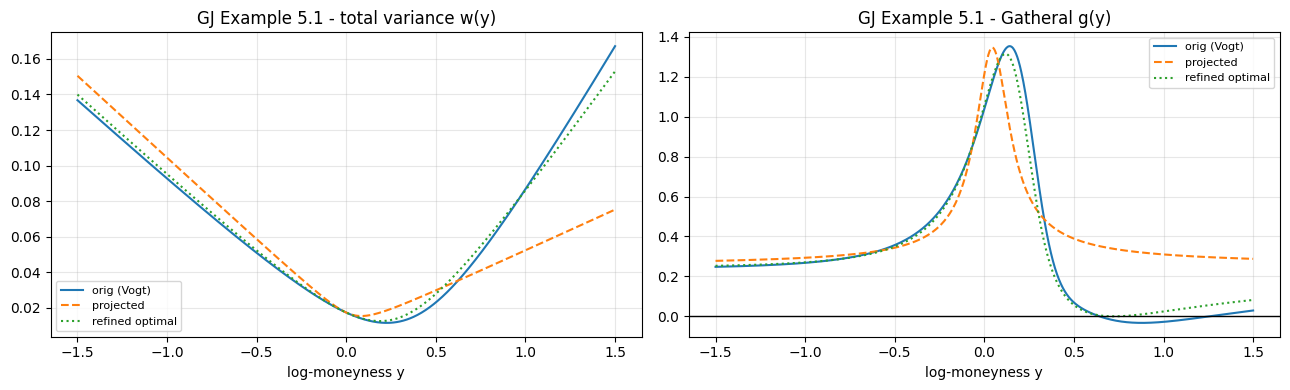

In [4]:
gj51 = art.reports.get('gj51')
if gj51 is None:
    print('GJ paper sanity check disabled for this run.')
else:
    gj_cmp = art.tables['gj51_comparison'].copy()
    gj_cmp['abs_error_vs_paper'] = (gj_cmp['computed'] - gj_cmp['paper']).abs()

    paper_targets = gj_cmp.loc[
        gj_cmp['quantity'].str.contains('JW\.|Section 5.1 target|Projected', regex=True)
    ].copy()
    gj_headline = pd.DataFrame(
        [
            {
                'max_abs_error_vs_paper_targets': float(paper_targets['abs_error_vs_paper'].max()),
                'mean_abs_error_vs_paper_targets': float(paper_targets['abs_error_vs_paper'].mean()),
                'projected_min_g': float(gj51.check_projected.min_g),
                'optimal_min_g': float(gj51.check_optimal.min_g),
            }
        ]
    )

    display(gj_headline)
    display(gj_cmp)
    display(art.tables['gj51_checks'])

    fig, ax = plt.subplots(1, 2, figsize=(13, 4))

    ax[0].plot(gj51.y_plot, gj51.w_raw, label='orig (Vogt)')
    ax[0].plot(gj51.y_plot, gj51.w_projected, linestyle='--', label='projected')
    ax[0].plot(gj51.y_plot, gj51.w_optimal, linestyle=':', label='refined optimal')
    ax[0].set_title(r'GJ Example 5.1 - total variance w(y)')
    ax[0].set_xlabel('log-moneyness y')
    ax[0].grid(True, alpha=0.3)
    ax[0].legend(fontsize=8)

    ax[1].plot(gj51.y_plot, gj51.g_raw, label='orig (Vogt)')
    ax[1].plot(gj51.y_plot, gj51.g_projected, linestyle='--', label='projected')
    ax[1].plot(gj51.y_plot, gj51.g_optimal, linestyle=':', label='refined optimal')
    ax[1].axhline(0.0, linewidth=1.0, color='black')
    ax[1].set_title('GJ Example 5.1 - Gatheral g(y)')
    ax[1].set_xlabel('log-moneyness y')
    ax[1].grid(True, alpha=0.3)
    ax[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()


## 4) Compare interpolation choices on a probe maturity

The `no_arb` and `linear_w` interpolants serve different downstream needs; the table and slice below keep that trade-off explicit before the smoother Dupire handoff in Demo 07.

,T_probe,mean_abs_iv_gap_bp,max_abs_iv_gap_bp,static_surface_story,dupire_story
0,0.415,13.049305,36.605944,no_arb,Demo 07 / eSSVI


,T_probe,y,K,iv_no_arb,iv_linear_w,abs_iv_gap_bp
0,0.415,-0.2500,78.529173,0.260257,0.257961,22.960570
1,0.415,-0.1875,83.593869,0.249466,0.248104,13.621306
2,0.415,-0.1250,88.985211,0.240113,0.239703,4.096648
3,0.415,-0.0625,94.724264,0.232660,0.233022,3.622212
4,0.415,0.0000,100.833454,0.227592,0.228302,7.098048
5,0.415,0.0625,107.336653,0.225299,0.225731,4.319789
6,0.415,0.1250,114.259272,0.225943,0.225422,5.214280
7,0.415,0.1875,121.628362,0.229381,0.227391,19.904949
8,0.415,0.2500,129.472718,0.235216,0.231556,36.605944


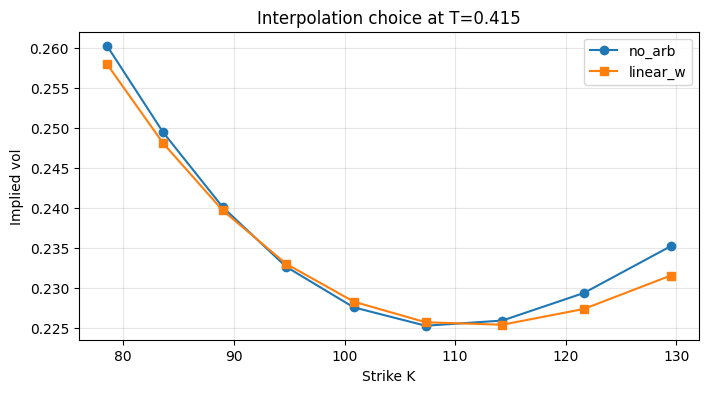

In [5]:
interp = art.tables['interpolation_choice'].copy()
interp_headline = pd.DataFrame(
    [
        {
            'T_probe': float(interp['T_probe'].iloc[0]),
            'mean_abs_iv_gap_bp': float(interp['abs_iv_gap_bp'].mean()),
            'max_abs_iv_gap_bp': float(interp['abs_iv_gap_bp'].max()),
            'static_surface_story': 'no_arb',
            'dupire_story': 'Demo 07 / eSSVI',
        }
    ]
)

display(interp_headline)
display(interp)

plt.figure(figsize=(8, 4))
plt.plot(interp['K'], interp['iv_no_arb'], marker='o', label='no_arb')
plt.plot(interp['K'], interp['iv_linear_w'], marker='s', label='linear_w')
plt.xlabel('Strike K')
plt.ylabel('Implied vol')
plt.title(f'Interpolation choice at T={float(interp["T_probe"].iloc[0]):g}')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## Outputs produced

- repaired SVI implied surface and surface-level no-arbitrage diagnostics
- quote-fit, flagged-slice, and repair summary tables
- Gatheral-Jacquier reference-case benchmark checks
- interpolation comparison on a shared probe maturity

The primary output here is a static implied-surface object; Demo 07 continues with the smoother Dupire-oriented handoff.